# **Transformers-based Approach**

## **1. Initial Set Up and Data Preparation**

### **1.1 Installing required Dependencies and Importing Libraries**

In [ ]:
!pip install transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 -q
!pip install sentencepiece==0.2.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 81.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.3 MB/s eta 0:00:00


In [ ]:
import os, json, random, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import Trainer
import torch.nn as nn

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


> **Gating Switch**: you can choose to load saved results or retrain from scratch.

In [ ]:
FORCE_RETRAIN = False
print(f"FORCE_RETRAIN = {FORCE_RETRAIN}")

FORCE_RETRAIN = False


> **Path Configuration**

In [ ]:
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/ARTEMIS_Sentiment_Analysis'
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

SPLITS_DIR       = os.path.join(PROJECT_ROOT, 'data', 'splits')
MODELS_DIR       = os.path.join(PROJECT_ROOT, 'models')
TRANSF_MODEL_DIR = os.path.join(MODELS_DIR, 'transformers')
TRANSF_RES       = os.path.join(PROJECT_ROOT, 'results', 'transformers')
TRANSF_FIG       = os.path.join(TRANSF_RES, 'figures')
for d in (TRANSF_MODEL_DIR, TRANSF_RES, TRANSF_FIG):
    os.makedirs(d, exist_ok=True)

# Per-model output folders
DISTILBERT_DIR = os.path.join(TRANSF_MODEL_DIR, 'distilbert')
ROBERTA_DIR    = os.path.join(TRANSF_MODEL_DIR, 'roberta')
DEBERTA_DIR    = os.path.join(TRANSF_MODEL_DIR, 'deberta')

Mounted at /content/drive


### **1.2 Data Preparation**

In [ ]:
train_df = pd.read_csv(os.path.join(SPLITS_DIR, 'train_split.csv'))
val_df   = pd.read_csv(os.path.join(SPLITS_DIR, 'val_split.csv'))
test_df  = pd.read_csv(os.path.join(SPLITS_DIR, 'test_split.csv'))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 4636 | Val: 993 | Test: 994


To ensure a rigorous and fair comparison between the Neural-Network-based models and our new Transformer-based models, we must train and evaluate them on the exact same data.

Instead of re-running a dynamic `train_test_split`, which could risk data leakage or slight variations due to library updates, we directly load the fixed partitions from our previously saved CSV files. This guarantees that the Train (4636), Validation (993), and Test (994) sets remain perfectly preserved and byte-identical across all experiments.




In [ ]:
with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

for d in (train_df, val_df, test_df):
    d['label_enc'] = label_encoder.transform(d['label'])

target_names = list(label_encoder.classes_)
num_labels   = len(target_names)
print(f"Classes ({num_labels}): {target_names}")

Classes (4): ['Conspiratorial', 'Critical/Skeptical', 'Enthusiastic', 'Neutral']



Just as we need identical data partitions, we also need an identical mapping between our text categories and the numerical IDs used by the models' classification heads.

By loading the pre-fitted `label_encoder.pkl` from our models directory, we ensure that the transformation remains strictly consistent. The `transform` method safely maps our string labels to integers (0 to 3), guaranteeing that class `0` always represents *Conspiratorial*, class `1` always represents *Critical/Skeptical*, and so on, preventing any misalignment when we later compare confusion matrices.

### **1.3 Class Weights Computation**

In [ ]:
classes_array = np.unique(train_df['label_enc'])
weights = compute_class_weight('balanced', classes=classes_array, y=train_df['label_enc'].values)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class weights:")
for name, w in zip(target_names, weights):
    print(f"  {name}: {w:.4f}")

Class weights:
  Conspiratorial: 2.9194
  Critical/Skeptical: 2.5529
  Enthusiastic: 0.5789
  Neutral: 0.6500


As discussed in our initial strategy, our dataset is heavily skewed toward *Enthusiastic* and *Neutral* tweets. If we train the models naively, they will naturally bias their predictions toward these majority classes to minimize overall error.

To prevent this, we calculate balanced class weights based on the inverse frequency of each label in the training set. Looking at the output, the mathematical penalty for misclassifying a *Conspiratorial* tweet (weight $\approx 2.92$) will be nearly five times higher than the penalty for missing an *Enthusiastic* one (weight $\approx 0.58$). We convert these weights into a PyTorch tensor (`class_weights`) so they can be natively processed by the GPU during backpropagation.



In [ ]:
def make_datasets(tokenizer, max_len=64):
    def to_ds(df):
        ds = Dataset.from_dict({'text': df['text'].tolist(), 'label': df['label_enc'].tolist()})
        return ds.map(lambda b: tokenizer(b['text'], truncation=True, max_length=max_len), batched=True)
    return to_ds(train_df), to_ds(val_df), to_ds(test_df)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits.view(-1, num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    return {'macro_f1': f1_score(pred.label_ids, pred.predictions.argmax(-1),
                                 average='macro', zero_division=0)}

### **1.4 Shared Training Components**

The three functions defined above set up the components shared by all three Transformer experiments, so that the models are trained and evaluated under identical conditions and any difference in results is attributable to the architecture rather than the setup.

1. **`make_datasets` (tokenization)**: Each Pandas split is converted into a Hugging Face `Dataset` and tokenized in optimized batches (`batched=True`) with the model-specific tokenizer. We set `max_length=64`: as shown in the length analysis of the previous notebooks, almost all tweets fall well within this limit, so truncation affects only a small minority of cases. Note that Transformer tokenizers operate on **subword units**
rather than whole words, so a tweet generally produces more tokens than its word count; 64 subword tokens is nonetheless sufficient to cover the large majority of tweets without
loss of content.

2. **`WeightedTrainer` (class-weighted loss)**: The standard Hugging Face `Trainer` applies an unweighted cross-entropy loss, which would let the model favour the majority classes. To apply the same imbalance strategy used for the recurrent models, we subclass `Trainer` and override `compute_loss`, replacing the default loss with a `CrossEntropyLoss` weighted by the per-class coefficients computed earlier (the `balanced` heuristic). Each class's
contribution to the loss is therefore scaled by its weight, so errors on the rare *Critical/Skeptical* and *Conspiratorial* classes count more heavily than errors on the majority classes.

3. **`compute_metrics` (evaluation metric)**: The evaluation loop reports the
**macro F1-score** (`average='macro'`), which weights all four classes equally and is the headline metric used throughout the project. Note, however, that model checkpointing during training is based on the **validation loss** (`metric_for_best_model="eval_loss"`), not on macro F1: validation loss provides a more stable criterion for selecting the best epoch, and using it consistently across all models keeps the checkpoint selection comparable.

## **2. DistilBERT**

### **2.1 Introduction to DistilBERT**

With our data pipeline and class-weighting strategy in place, we begin our Transformer
experiments with **DistilBERT** (Distilled BERT). We use this model as our "advanced baseline", a bridge between the recurrent neural networks explored previously and the heavier, more complex Transformers tested later.

Introduced by Hugging Face in 2019, DistilBERT was born out of a practical problem: the rapid growth in the size and computational cost of large language models. While the original BERT (Bidirectional Encoder Representations from Transformers) achieved state-of-the-art results across NLP tasks, it was heavy, slow, and expensive to deploy in latency-sensitive
production environments.

To address this, the authors used a technique called **Knowledge Distillation**, a compression method in which a smaller model (DistilBERT) is trained to reproduce the behaviour of a larger, pre-trained model (BERT). Instead of only learning to predict the final hard labels, the student learns to mimic the teacher's full probability distributions
(the soft targets), transferring the teacher's generalised knowledge into a much smaller architecture.

Through distillation, DistilBERT achieves a strong balance between performance and efficiency. Compared to the original BERT base model, DistilBERT is:

* **40% smaller**: it halves the number of transformer layers (from 12 to 6) and removes certain embeddings (such as token-type embeddings).
* **60% faster**: the reduction in parameters speeds up both training and inference.
* **Highly capable**: despite the compression, it retains about 97% of BERT's language understanding capabilities.

Its primary strength is operational efficiency: it allows rapid fine-tuning and deployment on standard hardware without large GPU clusters. However, because it has half the layers of BERT, it has reduced semantic capacity and can struggle with highly complex, deeply contextualised nuances or long-range reasoning that benefit from deeper attention.

A further point connects directly to the previous notebook. Unlike the word-level tokenizer used by the recurrent models, where rare or informal words were discarded as out-of-vocabulary tokens, DistilBERT uses **WordPiece subword tokenization**, which represents rare words as combinations of smaller subword units rather than dropping them. This directly addresses one of the limitations identified for the BiLSTM and ULMFiT.

Given the characteristics of our Artemis II X (Twitter) dataset, we expect DistilBERT to behave as follows:

1. Because tweets are short, long-range dependencies are rare. DistilBERT's reduced layer count should be sufficient to capture the sentiment of standard *Enthusiastic* or *Neutral* tweets.
2. Thanks to its self-attention mechanism, which processes the entire tweet bidirectionally, we expect DistilBERT to outperform the BiLSTM and ULMFiT, particularly in handling basic sarcasm and the contextual use of space-related terminology.
3. The harder test is the boundary between the *Critical/Skeptical* and *Conspiratorial* classes. Distinguishing a legitimate complaint about NASA's budget from a conspiracy theory often relies on subtle rhetorical cues or faux-technical jargon. DistilBERT's reduced semantic capacity may leave some confusion between these two classes, leaving room for the heavier RoBERTa and DeBERTa to improve the Macro F1-Score.

### **2.2 Model Training**

In [ ]:
DISTILBERT_CKPT = "distilbert-base-uncased"
DB_LR, DB_EPOCHS, DB_WD = 3e-5, 3, 0.01
db_history_path = os.path.join(TRANSF_RES, 'distilbert_history.json')

if os.path.exists(db_history_path) and not FORCE_RETRAIN:
    # ---- DISPLAY the saved training history (no retraining) ----
    with open(db_history_path, 'r') as f:
        db_history = json.load(f)
    print("DistilBERT training history loaded from saved file.\n")
    print(pd.DataFrame(db_history).to_string(index=False))
    h5_status = "found" if os.path.exists(DISTILBERT_DIR) else "MISSING (hosted externally)"

else:
    # ---- RETRAIN (FORCE_RETRAIN or no saved history) ----
    print(f"Training DistilBERT: lr={DB_LR}, epochs={DB_EPOCHS}, weight_decay={DB_WD}")
    db_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_CKPT)
    db_train, db_val, db_test = make_datasets(db_tokenizer, max_len=64)
    db_model = AutoModelForSequenceClassification.from_pretrained(
        DISTILBERT_CKPT, num_labels=num_labels).to(device)

    db_args = TrainingArguments(
        output_dir="tmp_distilbert_final",
        num_train_epochs=DB_EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=DB_LR,
        weight_decay=DB_WD,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        seed=SEED,
        report_to="none",
        log_level="error",
    )

    db_trainer = WeightedTrainer(model=db_model, args=db_args,
                                 train_dataset=db_train, eval_dataset=db_val,
                                 compute_metrics=compute_metrics, tokenizer=db_tokenizer)
    db_trainer.train()

    hist = pd.DataFrame(db_trainer.state.log_history)
    tr = hist[hist['loss'].notna()][['epoch', 'loss']].rename(columns={'loss': 'train_loss'})
    ev = hist[hist['eval_loss'].notna()][['epoch', 'eval_loss', 'eval_macro_f1']]
    db_history = pd.merge(tr, ev, on='epoch').round(4).to_dict(orient='list')

    os.makedirs(DISTILBERT_DIR, exist_ok=True)
    db_trainer.save_model(DISTILBERT_DIR)
    db_tokenizer.save_pretrained(DISTILBERT_DIR)
    with open(db_history_path, 'w') as f:
        json.dump(db_history, f, indent=2)
    print(f"\nModel + tokenizer saved to {DISTILBERT_DIR}")
    print(f"Training history saved to {db_history_path}")

DistilBERT training history loaded from saved file.

 epoch  train_loss  eval_loss  eval_macro_f1
   1.0      0.9914     0.7628         0.6733
   2.0      0.5262     0.7535         0.7144
   3.0      0.3009     0.8696         0.7243

Model folder: found


Fine-tuning a pre-trained Transformer requires careful calibration. Because the model already encodes a broad understanding of English, an excessively high learning rate can cause catastrophic forgetting, degrading its pre-trained representations, while training for too many epochs leads to overfitting on the training set.

To identify a suitable configuration for the Artemis II dataset, we ran several preliminary trials over the following hyperparameters:

* **Learning rate:** 2e-5 and 3e-5
* **Epochs:** 3 and 5
* **Weight decay (L2 regularization):** with and without

Based on the validation metrics across these trials, the most stable configuration for DistilBERT was a learning rate of **3e-5**, **3 epochs**, and a weight decay of **0.01**.

In the `TrainingArguments` below we set `load_best_model_at_end=True` and
`metric_for_best_model="eval_loss"`. Because Transformers converge quickly and tend to overfit in the final epochs, this configuration discards the final weights and restores the checkpoint with the lowest validation loss, so that the evaluation uses the best-generalizing version of the model. The training routine is wrapped in the `FORCE_RETRAIN` gating: by default the saved training history is loaded and displayed without retraining, preserving reproducibility.

The training logs follow the expected pattern:

* **Epoch 1:** the model adapts to the domain, reaching a validation loss of 0.762 and a
macro F1 of 0.673.
* **Epoch 2:** generalization peaks, with the lowest validation loss (0.753) and the highest
macro F1 (0.714).
* **Epoch 3:** overfitting sets in: the training loss falls sharply (from 0.526 to 0.300)
while the validation loss rises to 0.869.

Since `load_best_model_at_end=True`, the Trainer selects the Epoch 2 checkpoint. These are
the weights saved to `models/transformers/distilbert/` and used for the test-set evaluation.

### **2.3 Training vs. Validation Loss**

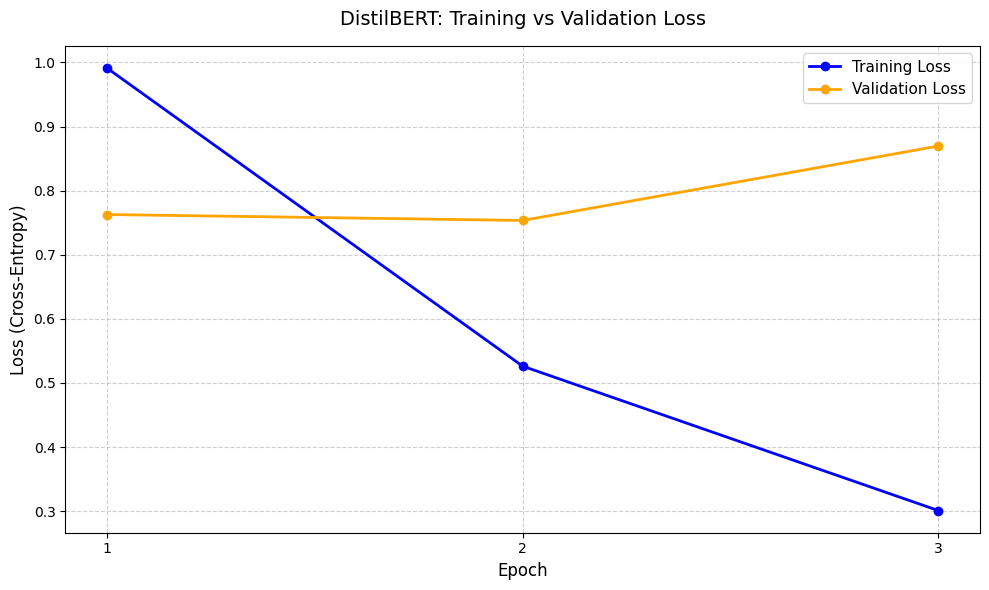

In [ ]:
epochs_range = db_history['epoch']

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, db_history['train_loss'], color='blue', marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs_range, db_history['eval_loss'], color='orange', marker='o', linewidth=2, label='Validation Loss')
plt.title('DistilBERT: Training vs Validation Loss', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.xticks(list(epochs_range))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The chart maps the training and validation loss across the three fine-tuning epochs.

* **Epochs 1–2:** both losses decrease, though the validation loss only slightly (from 0.762 to 0.753). The model is learning features that transfer to unseen data, and validation performance is at its best.
* **Epochs 2–3:** the curves diverge. The training loss keeps falling steeply (to 0.300), while the validation loss rises (to 0.869).

This divergence is the characteristic signature of overfitting: beyond Epoch 2 the model continues to fit the training set more closely, but these gains no longer generalize. The chart confirms the role of `load_best_model_at_end=True`, which restores the Epoch 2 checkpoint, the point of lowest validation loss and best generalization, rather than the
final, more overfit weights.

### **2.4 Test Set Evaluation**

DistilBERT — Test Macro F1: 0.7063

                    precision  recall  f1_score  support
Conspiratorial         0.6000  0.6353    0.6171     85.0
Critical/Skeptical     0.5124  0.6327    0.5662     98.0
Enthusiastic           0.8621  0.8159    0.8383    429.0
Neutral                0.8090  0.7984    0.8037    382.0


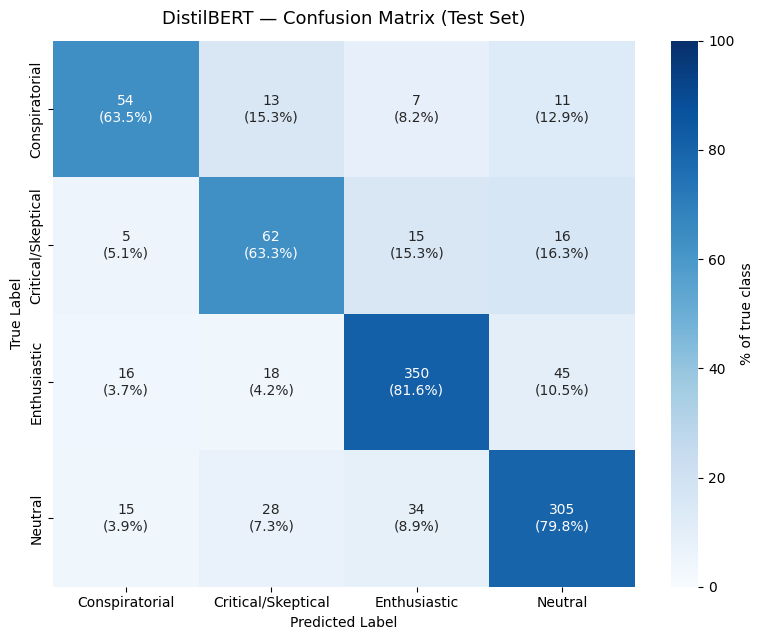

In [ ]:
db_summary_path = os.path.join(TRANSF_RES, 'distilbert_summary.json')

if os.path.exists(db_summary_path) and not FORCE_RETRAIN:
    # ---- DISPLAY saved evaluation results ----
    with open(db_summary_path, 'r') as f:
        db_summary = json.load(f)
    print(f"DistilBERT — Test Macro F1: {db_summary['test_macro_f1']:.4f}\n")
    pcm = pd.DataFrame(db_summary['per_class_metrics']).T
    print(pcm[['precision', 'recall', 'f1_score', 'support']].to_string())
    cm = np.array(db_summary['confusion_matrix'])
    class_names = db_summary['class_names']

else:
    # ---- LIVE evaluation on the test set + save ----
    pred_output = db_trainer.predict(db_test)
    test_probs  = pred_output.predictions
    test_preds  = test_probs.argmax(-1)
    test_labels = pred_output.label_ids

    test_macro_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)
    print(f"DistilBERT — Test Macro F1: {test_macro_f1:.4f}\n")
    print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))

    cm = confusion_matrix(test_labels, test_preds)
    class_names = target_names
    report = classification_report(test_labels, test_preds,
                                   target_names=target_names, output_dict=True, zero_division=0)

    # Save probs, confusion matrix, and summary
    np.save(os.path.join(TRANSF_RES, 'probs_distilbert.npy'), test_probs.astype(np.float32))
    np.save(os.path.join(TRANSF_RES, 'cm_distilbert.npy'), cm)

    db_summary = {
        'model_name': 'DistilBERT (fine-tuned)',
        'config': {'learning_rate': DB_LR, 'epochs': DB_EPOCHS, 'weight_decay': DB_WD},
        'test_macro_f1': round(float(test_macro_f1), 4),
        'class_names': target_names,
        'confusion_matrix': cm.tolist(),
        'classification_report': report,
        'per_class_metrics': {
            cls: {'precision': round(report[cls]['precision'], 4),
                  'recall': round(report[cls]['recall'], 4),
                  'f1_score': round(report[cls]['f1-score'], 4),
                  'support': int(report[cls]['support'])}
            for cls in target_names}
    }
    with open(db_summary_path, 'w') as f:
        json.dump(db_summary, f, indent=2)
    print(f"\nSaved summary to {db_summary_path}")

cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

annot = np.empty_like(cm).astype(str)
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        annot[r, c] = f"{cm[r, c]}\n({cm_pct[r, c]:.1f}%)"

plt.figure(figsize=(8, 6.5))
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=100, cbar_kws={'label': '% of true class'})
plt.title('DistilBERT — Confusion Matrix (Test Set)', fontsize=13, pad=12)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

Using the Epoch 2 checkpoint, DistilBERT is evaluated on the held-out test set (994 tweets), giving the measure of its generalization to unseen data.

DistilBERT reaches a **test macro F1** of **0.706**, a clear improvement over the recurrent baselines, which both settled around 0.66 (BiLSTM 0.660, ULMFiT 0.665). The gain confirms the expectation set out in the introduction: even the most compressed Transformer outperforms the word-level recurrent models on this task.

The improvement is concentrated where it matters most: the minority classes. The recurrent models combined low precision on both *Conspiratorial* (0.43–0.59) and *Critical/Skeptical* (0.44–0.45) with substantial leakage between the two. DistilBERT raises *Conspiratorial* precision to 0.60 and *Critical/Skeptical* precision to 0.51, while keeping recall high (0.64 and 0.63). Processing the whole tweet through self-attention rather than sequential recurrence, and using subword tokenization instead of a fixed word vocabulary, lets it separate the two skeptical classes more reliably than the recurrent models did.

The confusion matrix shows the expected split between majority and minority dynamics:

* **Majority classes**: *Enthusiastic* (precision 0.86, recall 0.82) and *Neutral* (0.81 / 0.80) are classified well. Notably, the model rarely mistakes factual or numerical tweets for conspiratorial content, a failure mode seen in the recurrent models, where dense historical or telemetry references were often misread as denial.

* **Critical/Skeptical vs. Conspiratorial**: Class weighting lifts recall on both minority classes (0.64 and 0.63), but precision remains the weaker point, as anticipated. The matrix shows the residual confusion is mutual: 15.3% of true *Conspiratorial* tweets are predicted *Critical/Skeptical*, and 15.3% of true *Critical/Skeptical* tweets are predicted *Enthusiastic*
or *Neutral*. This reflects the heavy vocabulary overlap identified in the `02_exploratory_data_analysis`: both classes share language around cost, institutional distrust, and technical doubt.

DistilBERT's reduced depth (6 layers rather than BERT's 12) gives it less semantic capacity for the finest distinctions: it reliably detects the broad skeptical tone but is less precise in separating the two minority classes, which share much of their vocabulary. This is the boundary the heavier RoBERTa and DeBERTa are introduced to test next.

## **3. RoBERTa**

### **3.1 Introduction to RoBERTa**

Following the evaluation of DistilBERT, we move to a heavier, uncompressed Transformer architecture: **RoBERTa** (Robustly Optimized BERT Approach). While DistilBERT served as a lean, speed-optimized baseline, RoBERTa is included to test how a fully optimized language model handles the subtle rhetorical boundaries of our dataset.

Released by Facebook AI (Meta) and the University of Washington in late 2019, RoBERTa was developed in response to a finding about Google's original BERT model: BERT was undertrained. Rather than changing the core architecture of BERT (the standard bidirectional Transformer encoder), the authors revised its training procedure, showing that an improved training recipe alone could substantially exceed BERT's original benchmark performance.

RoBERTa improves on BERT through four main adjustments:

1. **Larger-scale training**: it was trained on roughly 10 times more data (160GB vs. BERT's 16GB), with larger batch sizes and a longer training schedule.
2. **Dynamic masking**: BERT uses static masking, where the masked tokens are fixed during preprocessing and remain the same across epochs. RoBERTa re-samples the masked tokens each time a sequence is seen, exposing the model to more contextual variation.
3. **Removal of Next Sentence Prediction (NSP)**: BERT is trained on masked-word prediction and on judging whether one sentence follows another. RoBERTa removes the NSP task and trains on continuous blocks of text, which the authors found improves downstream classification.
4. **Byte-level tokenizer**: unlike BERT's WordPiece tokenizer, RoBERTa uses a byte-level Byte-Pair Encoding (BPE) vocabulary, which handles rare words, slang, and informal spelling without falling back on generic unknown tokens.

Compared with DistilBERT, RoBERTa retains the full **12-layer encoder** (twice the depth of DistilBERT's 6), giving it more capacity to model abstract linguistic patterns and therefore
greater semantic capability. Its byte-level BPE tokenizer is also better suited to noisy social-media text (typos, hashtags, specialized terminology) than DistilBERT's WordPiece vocabulary. The cost is computational: with double the layers, RoBERTa takes roughly twice as long per epoch and requires more memory at inference.

Considering the errors observed for DistilBERT, we expect RoBERTa to behave as follows on the Artemis II corpus:

* DistilBERT dispersed *Critical/Skeptical* tweets into *Neutral* (16.3%) and *Enthusiastic*
(15.3%). With its deeper encoder and improved pre-training, RoBERTa may be more sensitive to the
critical edge or sarcasm that separates a complaint from an objective status update, reducing
this dispersion.
* Public discourse around space programs on X is highly informal. RoBERTa's byte-level
tokenizer and broad web pre-training should help it interpret slang, hashtags, and specialized
jargon. Note that emojis have already been converted to text during preprocessing, so this
advantage applies to informal wording rather than to emoji glyphs.
* We therefore expect RoBERTa to reach a higher macro F1 than DistilBERT, driven mainly by
cleaner precision and recall on the two minority classes (*Critical/Skeptical* and
*Conspiratorial*).

### **3.2 Model Training**

In [ ]:
ROBERTA_CKPT = "roberta-base"
RB_LR, RB_EPOCHS, RB_WD = 3e-5, 3, 0.01
rb_history_path = os.path.join(TRANSF_RES, 'roberta_history.json')

if os.path.exists(rb_history_path) and not FORCE_RETRAIN:
    # ---- DISPLAY the saved training history (no retraining) ----
    with open(rb_history_path, 'r') as f:
        rb_history = json.load(f)
    print("RoBERTa training history loaded from saved file.\n")
    print(pd.DataFrame(rb_history).to_string(index=False))
    rb_status = "found" if os.path.exists(ROBERTA_DIR) else "MISSING (hosted externally)"
    print(f"\nModel folder: {rb_status}")

else:
    # ---- RETRAIN (FORCE_RETRAIN or no saved history) ----
    print(f"Training RoBERTa: lr={RB_LR}, epochs={RB_EPOCHS}, weight_decay={RB_WD}")
    rb_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_CKPT)
    rb_train, rb_val, rb_test = make_datasets(rb_tokenizer, max_len=64)
    rb_model = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_CKPT, num_labels=num_labels).to(device)

    rb_args = TrainingArguments(
        output_dir="tmp_roberta_final",
        num_train_epochs=RB_EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=RB_LR,
        weight_decay=RB_WD,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        seed=SEED,
        report_to="none",
        log_level="error",
    )

    rb_trainer = WeightedTrainer(model=rb_model, args=rb_args,
                                 train_dataset=rb_train, eval_dataset=rb_val,
                                 compute_metrics=compute_metrics, tokenizer=rb_tokenizer)
    rb_trainer.train()

    hist = pd.DataFrame(rb_trainer.state.log_history)
    tr = hist[hist['loss'].notna()][['epoch', 'loss']].rename(columns={'loss': 'train_loss'})
    ev = hist[hist['eval_loss'].notna()][['epoch', 'eval_loss', 'eval_macro_f1']]
    rb_history = pd.merge(tr, ev, on='epoch').round(4).to_dict(orient='list')

    os.makedirs(ROBERTA_DIR, exist_ok=True)
    rb_trainer.save_model(ROBERTA_DIR)
    rb_tokenizer.save_pretrained(ROBERTA_DIR)
    with open(rb_history_path, 'w') as f:
        json.dump(rb_history, f, indent=2)
    print(f"\nModel + tokenizer saved to {ROBERTA_DIR}")
    print(f"Training history saved to {rb_history_path}")

RoBERTa training history loaded from saved file.

 epoch  train_loss  eval_loss  eval_macro_f1
   1.0      0.9449     0.7356         0.7244
   2.0      0.5064     0.6407         0.7384
   3.0      0.2906     0.8633         0.7608

Model folder: found


To keep the comparison controlled, RoBERTa was tuned with the same procedure used for DistilBERT, over a grid of learning rates (2e-5, 3e-5), epochs (3, 4), and weight decay (with and without 0.01). The most stable configuration was a learning rate of **3e-5**, **3 epochs**, and a weight decay of **0.01**: identical to the DistilBERT setup.

Holding these hyperparameters fixed isolates the architecture as the main variable, so that differences in performance or in the class boundaries can be attributed to RoBERTa's depth, pre-training, and tokenization rather than to the training configuration. As before, `load_best_model_at_end=True` with `metric_for_best_model="eval_loss"` selects the checkpoint with the lowest validation loss.

The training logs show the following:

* **Epoch 1:** RoBERTa reaches a validation loss of 0.7356 and a macro F1 of 0.7244,
already ahead of DistilBERT's first epoch (0.7627 loss / 0.6733 F1), reflecting its larger
capacity and more extensive pre-training.
* **Epoch 2:** generalization peaks, with the lowest validation loss (**0.6406**) and a macro
F1 of **0.7384**.
* **Epoch 3:** the training loss falls to 0.2906 while the validation loss rises to 0.8632; the validation macro F1 reaches its highest nominal value (0.7608).

The third epoch illustrates a divergence between the two validation metrics: macro F1 increases while validation loss worsens. This happens because cross-entropy loss measures the calibration of the predicted probabilities, not only whether the predicted class is correct.
As the model overfits, it becomes more confident; when a confident prediction is wrong, the loss is penalized heavily, so the loss can rise even as the proportion of correct predictions (and thus F1) improves. Because checkpoint selection is tied to validation loss, the pipeline
keeps the **Epoch 2** weights, better calibrated and more stable.

### **3.3 Training vs. Validation Loss**

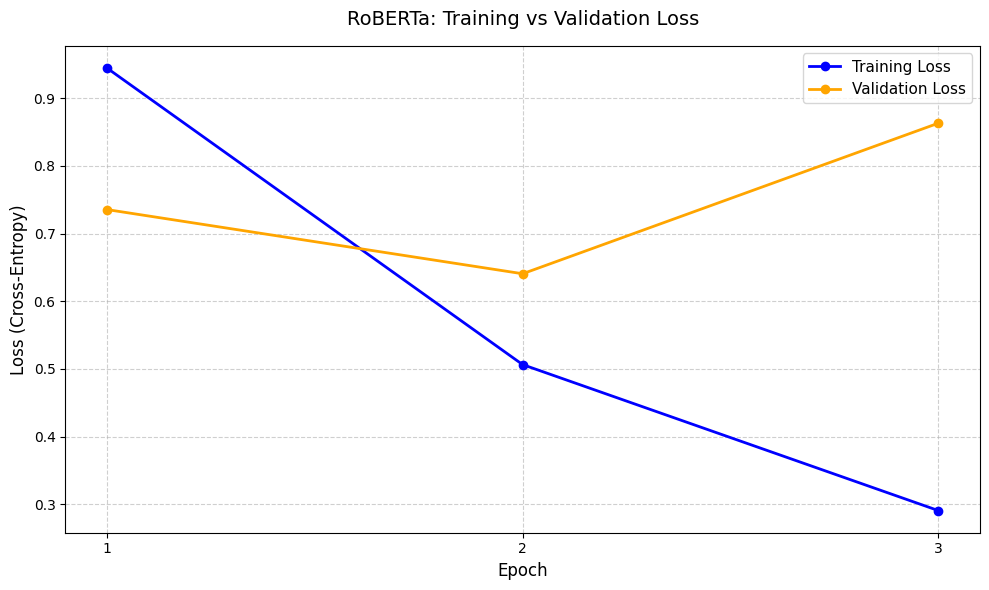

In [ ]:
epochs_range = rb_history['epoch']

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, rb_history['train_loss'], color='blue', marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs_range, rb_history['eval_loss'], color='orange', marker='o', linewidth=2, label='Validation Loss')
plt.title('RoBERTa: Training vs Validation Loss', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.xticks(list(epochs_range))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The chart maps the training and validation loss across the three fine-tuning epochs.

* **Epochs 1–2:** both losses decrease, the training loss steeply and the validation loss
more gradually (from 0.7356 to 0.6406). RoBERTa adapts to the domain while still improving on
the validation set, which reaches its best point at Epoch 2.
* **Epochs 2–3:** the curves diverge. The training loss continues to fall (to 0.2906), while
the validation loss rises to 0.8632.

This pattern matches the one observed for DistilBERT: both models reach their lowest validation loss at Epoch 2, after which further training only fits the training set more closely without improving generalization. RoBERTa's minimum validation loss (**0.6406**) is lower than
DistilBERT's (0.7535), consistent with the greater capacity of the full 12-layer encoder.

Because checkpoint selection is tied to the minimum validation loss, the pipeline keeps the Epoch 2 weights, better calibrated than the more overfit Epoch 3, for the test-set
evaluation.

### **3.4 Test Set Evaluation**

RoBERTa — Test Macro F1: 0.7665

                    precision  recall  f1_score  support
Conspiratorial         0.6774  0.7412    0.7079     85.0
Critical/Skeptical     0.5887  0.7449    0.6577     98.0
Enthusiastic           0.8862  0.8531    0.8694    429.0
Neutral                0.8516  0.8115    0.8311    382.0


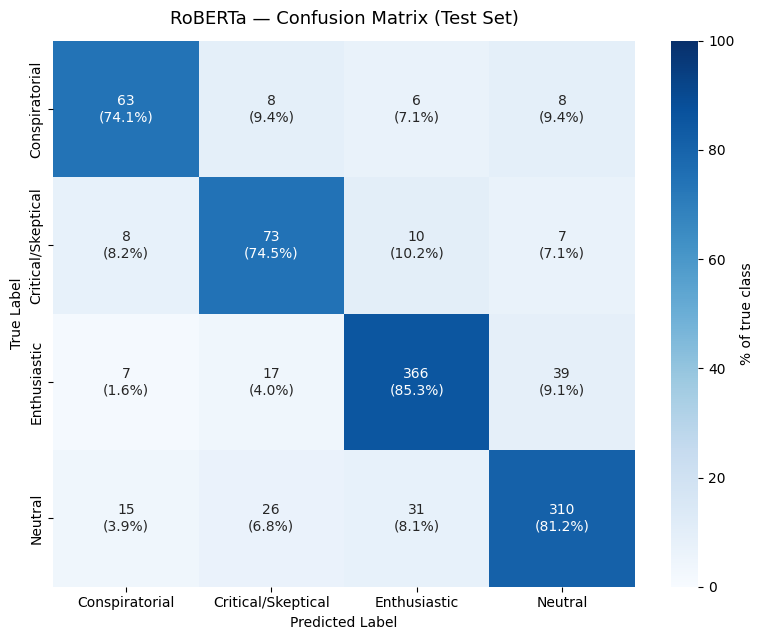

In [ ]:
rb_summary_path = os.path.join(TRANSF_RES, 'roberta_summary.json')

if os.path.exists(rb_summary_path) and not FORCE_RETRAIN:
    # ---- DISPLAY saved evaluation results ----
    with open(rb_summary_path, 'r') as f:
        rb_summary = json.load(f)
    print(f"RoBERTa — Test Macro F1: {rb_summary['test_macro_f1']:.4f}\n")
    pcm = pd.DataFrame(rb_summary['per_class_metrics']).T
    print(pcm[['precision', 'recall', 'f1_score', 'support']].to_string())
    cm = np.array(rb_summary['confusion_matrix'])
    class_names = rb_summary['class_names']

else:
    # ---- LIVE evaluation on the test set + save ----
    pred_output = rb_trainer.predict(rb_test)
    test_probs  = pred_output.predictions
    test_preds  = test_probs.argmax(-1)
    test_labels = pred_output.label_ids

    test_macro_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)
    print(f"RoBERTa — Test Macro F1: {test_macro_f1:.4f}\n")
    print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))

    cm = confusion_matrix(test_labels, test_preds)
    class_names = target_names
    report = classification_report(test_labels, test_preds,
                                   target_names=target_names, output_dict=True, zero_division=0)

    np.save(os.path.join(TRANSF_RES, 'probs_roberta.npy'), test_probs.astype(np.float32))
    np.save(os.path.join(TRANSF_RES, 'cm_roberta.npy'), cm)

    rb_summary = {
        'model_name': 'RoBERTa (fine-tuned)',
        'config': {'learning_rate': RB_LR, 'epochs': RB_EPOCHS, 'weight_decay': RB_WD},
        'test_macro_f1': round(float(test_macro_f1), 4),
        'class_names': target_names,
        'confusion_matrix': cm.tolist(),
        'classification_report': report,
        'per_class_metrics': {
            cls: {'precision': round(report[cls]['precision'], 4),
                  'recall': round(report[cls]['recall'], 4),
                  'f1_score': round(report[cls]['f1-score'], 4),
                  'support': int(report[cls]['support'])}
            for cls in target_names}
    }
    with open(rb_summary_path, 'w') as f:
        json.dump(rb_summary, f, indent=2)
    print(f"\nSaved summary to {rb_summary_path}")


cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

annot = np.empty_like(cm).astype(str)
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        annot[r, c] = f"{cm[r, c]}\n({cm_pct[r, c]:.1f}%)"

plt.figure(figsize=(8, 6.5))
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=100, cbar_kws={'label': '% of true class'})
plt.title('RoBERTa — Confusion Matrix (Test Set)', fontsize=13, pad=12)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

Using the Epoch 2 checkpoint, RoBERTa is evaluated on the held-out test set.

RoBERTa reaches a **test macro F1 of 0.766**, the highest of the three models so far. This is a clear improvement over the recurrent baselines (around 0.66) and over DistilBERT (0.706), consistent with the expectation that the full 12-layer encoder and RoBERTa's pre-training recipe provide more capacity for the harder distinctions in this corpus. The gain over DistilBERT is concentrated in the minority classes, which is where the macro F1 difference
originates.

The confusion matrix shows improvements across all four classes relative to DistilBERT:

* **Majority classes**: *Enthusiastic* reaches 85.3% recall (366/429, up from 81.6%) and *Neutral* 81.2% (310/382, up from 79.8%). Both majority classes were already handled well by DistilBERT; RoBERTa improves them modestly.

* **Critical/Skeptical**: This is the clearest gain. DistilBERT dispersed this class heavily into *Neutral* (16.3%) and *Enthusiastic* (15.3%), reaching only 63.3% recall. RoBERTa raises recall to 74.5% (73/98) and reduces that dispersion (10.2% to *Enthusiastic*, 7.1% to
*Neutral*), while precision rises from 0.51 to 0.59. The class the previous models found most unstable is now considerably better separated.

* **Conspiratorial**: Recall improves from 63.5% to 74.1% (63/85), and precision from 0.60 to 0.68. The leakage into *Critical/Skeptical*, the overlap repeatedly identified as the hardest
boundary, drops to 9.4% (8 tweets), down from 15.3% under DistilBERT.

In short, RoBERTa improves every class over DistilBERT, but the meaningful gains are on the two minority classes: both their recall and their precision rise, and the mutual confusion between *Conspiratorial* and *Critical/Skeptical*, the central difficulty since the exploratory
analysis, is reduced. This is consistent with the hypothesis stated in the introduction, that a deeper, fully-trained encoder would handle the minority boundary more reliably than the compressed DistilBERT.

## **4. DeBERTa**

### **4.1 Introduction to DeBERTa**

For the final Transformer experiment, we use the most advanced architecture in the pipeline:
**DeBERTa** (Decoding-enhanced BERT with disentangled attention). While DistilBERT provided
structural efficiency and RoBERTa maximized pre-training scale, DeBERTa modifies the
underlying self-attention mechanism itself.

Developed by Microsoft Research in late 2020, DeBERTa was designed to address a structural
limitation shared by BERT, RoBERTa, and most standard Transformers. In those architectures, a
word's meaning (its content) and its location in the sentence (its absolute position) are
summed into a single vector at the input layer. The DeBERTa authors argued that this early
blending forces the attention layers to conflate content and syntax, limiting the model's
ability to handle complex grammatical structure. DeBERTa keeps content and position separated
throughout the network.

DeBERTa introduces two main changes:

**Disentangled attention.** Each token is represented by two separate vectors: one for its
**content** and one for its **relative position**. When computing attention, the model
explicitly combines these through three interactions:

* **Content-to-content:** how the meaning of word A relates to the meaning of word B.
* **Content-to-position:** how the meaning of word A depends on a word at relative position B.
* **Position-to-content:** how the position of word A influences the meaning of a word at B.

**Enhanced Masked Decoder (EMD).** Relative position alone does not capture absolute location,
which is still needed for global sentence structure. Standard BERT adds absolute positions at
the input; DeBERTa instead injects them just before the final prediction layer, improving the
model's awareness of word order.

The version used here is **DeBERTa-v3**, which keeps the disentangled attention of the original
DeBERTa but changes the pre-training objective. Instead of masked-language modeling, v3 adopts
an ELECTRA-style *replaced-token detection* task, in which the model learns to identify which
tokens in a sentence have been replaced by a small generator network. This objective is more
sample-efficient than masked-language modeling and gives DeBERTa-v3 stronger performance than
the original DeBERTa at the same model size.

The three Transformers therefore differ along different axes. DistilBERT is a compressed,
lean baseline that trades depth for speed. RoBERTa keeps the standard BERT architecture but
scales up the training data, batch sizes, and duration. DeBERTa instead re-engineers the
attention mechanism itself, modeling word position more explicitly than its predecessors. It
is also the most computationally demanding of the three, with the largest model size and the
slowest training and inference.

Given the informal nature of the Artemis II corpus, DeBERTa's separation of content and
position may help with cases where word order changes sentiment, for example, negation or
inversions, which are common in social-media debate. However, our expectations remain
grounded in the constraints of the dataset:

* We expect DeBERTa to perform at a level comparable to RoBERTa, with its disentangled
attention potentially helping on sarcasm and word-order-dependent cases.
* While DeBERTa is architecturally stronger than RoBERTa on large benchmarks, the gain may be
limited here. Real-world classification reaches diminishing returns dictated by sample size,
short context length (tweets under 64 tokens), and the inherent human ambiguity in annotating
social-media sentiment, so we may already be near the ceiling this dataset allows.

### **4.2 Model Training**

In [ ]:
DEBERTA_CKPT = "microsoft/deberta-v3-base"
DE_LR, DE_EPOCHS, DE_WD = 2e-5, 3, 0.01
de_history_path = os.path.join(TRANSF_RES, 'deberta_history.json')

if os.path.exists(de_history_path) and not FORCE_RETRAIN:
    # ---- DISPLAY the saved training history (no retraining) ----
    with open(de_history_path, 'r') as f:
        de_history = json.load(f)
    print("DeBERTa training history loaded from saved file.\n")
    print(pd.DataFrame(de_history).to_string(index=False))
    de_status = "found" if os.path.exists(DEBERTA_DIR) else "MISSING (hosted externally)"
    print(f"\nModel folder: {de_status}")

else:
    # ---- RETRAIN (FORCE_RETRAIN or no saved history) ----
    print(f"Training DeBERTa: lr={DE_LR}, epochs={DE_EPOCHS}, weight_decay={DE_WD}")
    de_tokenizer = AutoTokenizer.from_pretrained(DEBERTA_CKPT)
    de_train, de_val, de_test = make_datasets(de_tokenizer, max_len=64)
    de_model = AutoModelForSequenceClassification.from_pretrained(
        DEBERTA_CKPT, num_labels=num_labels).float().to(device)

    de_args = TrainingArguments(
        output_dir="tmp_deberta_final",
        num_train_epochs=DE_EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=DE_LR,
        weight_decay=DE_WD,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        seed=SEED,
        report_to="none",
        log_level="error",
        fp16=False,
    )

    de_trainer = WeightedTrainer(model=de_model, args=de_args,
                                 train_dataset=de_train, eval_dataset=de_val,
                                 compute_metrics=compute_metrics, tokenizer=de_tokenizer)
    de_trainer.train()

    hist = pd.DataFrame(de_trainer.state.log_history)
    tr = hist[hist['loss'].notna()][['epoch', 'loss']].rename(columns={'loss': 'train_loss'})
    ev = hist[hist['eval_loss'].notna()][['epoch', 'eval_loss', 'eval_macro_f1']]
    de_history = pd.merge(tr, ev, on='epoch').round(4).to_dict(orient='list')

    os.makedirs(DEBERTA_DIR, exist_ok=True)
    de_trainer.save_model(DEBERTA_DIR)
    de_tokenizer.save_pretrained(DEBERTA_DIR)
    with open(de_history_path, 'w') as f:
        json.dump(de_history, f, indent=2)
    print(f"\nModel + tokenizer saved to {DEBERTA_DIR}")
    print(f"Training history saved to {de_history_path}")

DeBERTa training history loaded from saved file.

 epoch  train_loss  eval_loss  eval_macro_f1
   1.0      1.0281     0.8572         0.7052
   2.0      0.5666     0.6637         0.7466
   3.0      0.3828     0.7367         0.7671

Model folder: found


For the final Transformer, we kept the same tuning procedure used for DistilBERT and RoBERTa,
with one change to the grid: the **learning rate** was lowered to **2e-5**, from the 3e-5 used for
the other two models. DeBERTa-v3 is more sensitive to the learning rate during fine-tuning,
its disentangled content and position components, combined with the ELECTRA-style pre-training,
make a higher rate more prone to instability on short text. A learning rate of 2e-5 gives a
more stable fine-tuning trajectory, allowing the model to adapt to the Artemis II classes
without the validation loss diverging too early.

The training logs show the following:

* **Epoch 1:** validation loss 0.8572, macro F1 0.7052. The loss starts higher than RoBERTa's,
but the macro F1 already matches DistilBERT's best result.
* **Epoch 2:** validation loss reaches its minimum (**0.6637**) and macro F1 rises to **0.7466**.
* **Epoch 3:** the training loss falls to 0.3828 while the validation loss rises to 0.7367; the
macro F1 reaches its highest nominal value (0.7671).

The third-epoch divergence is milder than RoBERTa's: RoBERTa's validation loss rose from 0.6406
to 0.8632 between Epochs 2 and 3, whereas DeBERTa's rises only from 0.6637 to 0.7367. The macro
F1 settling in roughly the 0.74–0.77 range is consistent with the ceiling anticipated in the
introduction: although DeBERTa is architecturally stronger than standard BERT-family models, it
does not move substantially beyond RoBERTa's results on this dataset.

This is consistent with the dataset reaching the limit of the signal it can provide. The
remaining errors are less a matter of model design than of the intrinsic difficulty of the
data: short tweet length, informal phrasing, and the human ambiguity in annotating social-media
sentiment.

As with the other models, checkpoint selection is tied to the minimum validation loss, so the
Trainer keeps the Epoch 2 weights — the best-calibrated state — for the test-set evaluation.

### **4.3 Train vs. Validation Loss**

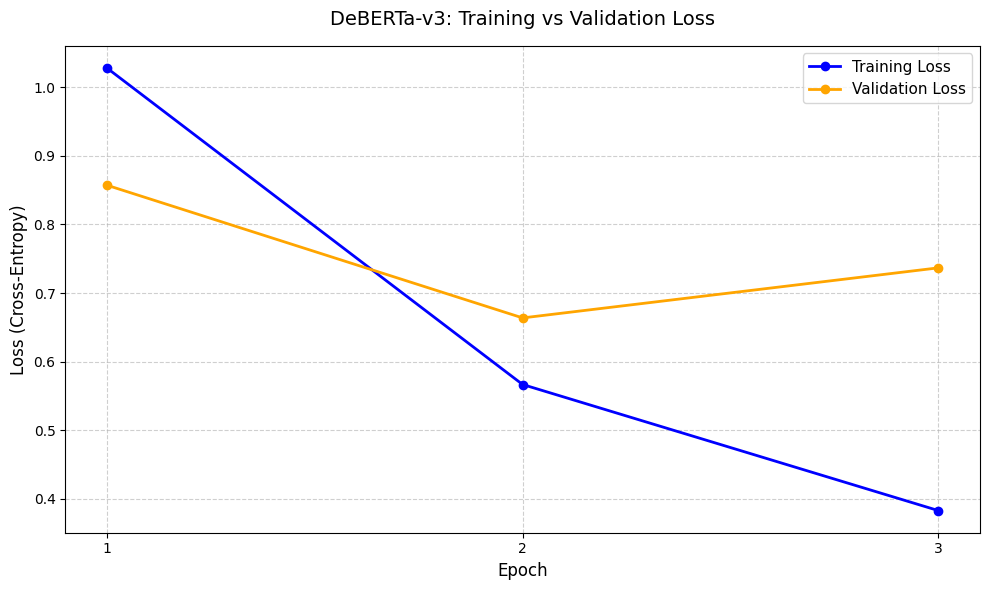

In [ ]:
epochs_range = de_history['epoch']

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, de_history['train_loss'], color='blue', marker='o', linewidth=2, label='Training Loss')
plt.plot(epochs_range, de_history['eval_loss'], color='orange', marker='o', linewidth=2, label='Validation Loss')
plt.title('DeBERTa-v3: Training vs Validation Loss', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.xticks(list(epochs_range))
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The chart maps DeBERTa-v3's training and validation loss across the three fine-tuning epochs.

* **Epochs 1–2:** both losses fall, the training loss steeply and the validation loss more
gradually (0.8572 to 0.6637), which is its minimum.
* **Epochs 2–3:** the training loss continues down to 0.3828, while the validation loss rises
mildly to 0.7367.

The minimum validation loss is reached at Epoch 2, and the subsequent rise is smaller than for
the other two models, indicating a more contained degree of overfitting. The Epoch 2 checkpoint
is therefore selected for evaluation.

### **4.3 Test Set Evaluation**

DeBERTa — Test Macro F1: 0.7698

                    precision  recall  f1_score  support
Conspiratorial         0.7397  0.6353    0.6835     85.0
Critical/Skeptical     0.5662  0.7857    0.6581     98.0
Enthusiastic           0.8798  0.9044    0.8920    429.0
Neutral                0.8924  0.8037    0.8457    382.0


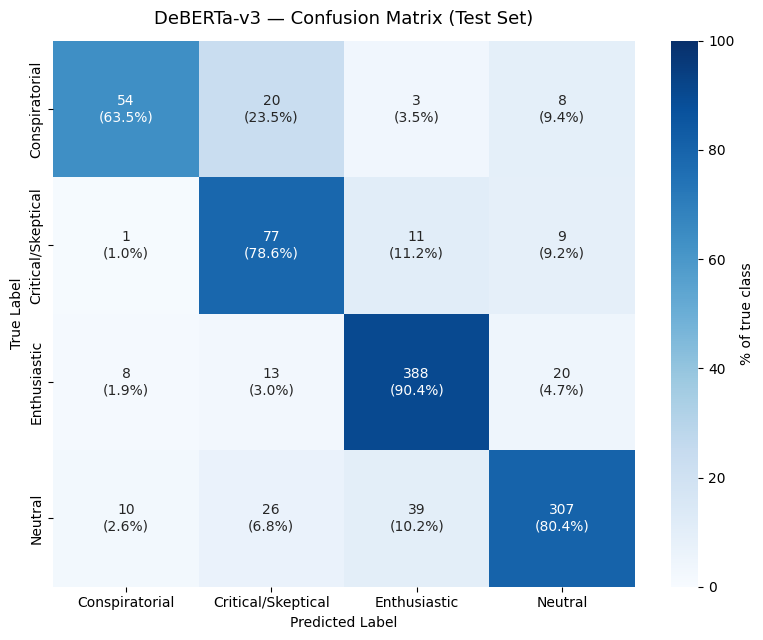

In [ ]:
de_summary_path = os.path.join(TRANSF_RES, 'deberta_summary.json')

if os.path.exists(de_summary_path) and not FORCE_RETRAIN:
    # ---- DISPLAY saved evaluation results ----
    with open(de_summary_path, 'r') as f:
        de_summary = json.load(f)
    print(f"DeBERTa — Test Macro F1: {de_summary['test_macro_f1']:.4f}\n")
    pcm = pd.DataFrame(de_summary['per_class_metrics']).T
    print(pcm[['precision', 'recall', 'f1_score', 'support']].to_string())
    cm = np.array(de_summary['confusion_matrix'])
    class_names = de_summary['class_names']

else:
    # ---- LIVE evaluation on the test set + save ----
    pred_output = de_trainer.predict(de_test)
    test_probs  = pred_output.predictions
    test_preds  = test_probs.argmax(-1)
    test_labels = pred_output.label_ids

    test_macro_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)
    print(f"DeBERTa — Test Macro F1: {test_macro_f1:.4f}\n")
    print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))

    cm = confusion_matrix(test_labels, test_preds)
    class_names = target_names
    report = classification_report(test_labels, test_preds,
                                   target_names=target_names, output_dict=True, zero_division=0)

    np.save(os.path.join(TRANSF_RES, 'probs_deberta.npy'), test_probs.astype(np.float32))
    np.save(os.path.join(TRANSF_RES, 'cm_deberta.npy'), cm)

    de_summary = {
        'model_name': 'DeBERTa-v3 (fine-tuned)',
        'config': {'learning_rate': DE_LR, 'epochs': DE_EPOCHS, 'weight_decay': DE_WD},
        'test_macro_f1': round(float(test_macro_f1), 4),
        'class_names': target_names,
        'confusion_matrix': cm.tolist(),
        'classification_report': report,
        'per_class_metrics': {
            cls: {'precision': round(report[cls]['precision'], 4),
                  'recall': round(report[cls]['recall'], 4),
                  'f1_score': round(report[cls]['f1-score'], 4),
                  'support': int(report[cls]['support'])}
            for cls in target_names}
    }
    with open(de_summary_path, 'w') as f:
        json.dump(de_summary, f, indent=2)
    print(f"\nSaved summary to {de_summary_path}")

cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

annot = np.empty_like(cm).astype(str)
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        annot[r, c] = f"{cm[r, c]}\n({cm_pct[r, c]:.1f}%)"

plt.figure(figsize=(8, 6.5))
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=100, cbar_kws={'label': '% of true class'})
plt.title('DeBERTa-v3 — Confusion Matrix (Test Set)', fontsize=13, pad=12)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

Using the Epoch 2 checkpoint, DeBERTa-v3 is evaluated on the held-out test set.

DeBERTa-v3 reaches a **test macro F1** of **0.770**, marginally above RoBERTa (0.766) and clearly
above DistilBERT (0.706). The difference from RoBERTa ($\approx 0.003$) is well
within the range of run-to-run and test-set sampling variation, so the two heavier Transformers
are best regarded as performing at the same level rather than one outperforming the other. This
is consistent with the ceiling anticipated in the introduction: beyond a certain capacity, the
limiting factor is the dataset rather than the architecture.

The confusion matrix shows where DeBERTa's behaviour differs from the other two:

* **Majority classes.** DeBERTa is the strongest of the three here: *Enthusiastic* reaches 90.4%
recall (F1 0.89) and *Neutral* 80.4% (F1 0.85), both slightly above RoBERTa and clearly above
DistilBERT. The dominant classes are now classified with high reliability.

* **Conspiratorial.** DeBERTa and RoBERTa reach similar F1 (0.68 vs 0.71) by opposite routes.
RoBERTa favours recall (74%), catching more conspiratorial tweets; DeBERTa favours precision
(0.74 vs RoBERTa's 0.68), flagging fewer but more confidently. DeBERTa's recall (63.5%) is lower, notably, 23.5% of its *Conspiratorial* tweets are predicted *Critical/Skeptical*, a higher
leak than RoBERTa's 9.4%. DeBERTa is therefore more conservative on this class.

* **Critical/Skeptical.** DeBERTa achieves the highest recall of any model on this class (78.6%,
77/98), with the leakage into *Enthusiastic* and *Neutral* reduced to 11.2% and 9.2%. Its
precision (0.57) is marginally below RoBERTa's (0.59), giving the same F1 (0.66).

Compared with DistilBERT, both heavier models represent a clear step up, particularly on the
minority classes: DistilBERT's *Critical/Skeptical* F1 of 0.57 rises to 0.66 in both RoBERTa and
DeBERTa, and its *Conspiratorial* F1 of 0.62 rises to 0.68–0.71. The improvement confirms that
the additional depth and pre-training of the full-size models help precisely where DistilBERT's
reduced capacity was weakest, the boundary between the two minority classes.

Between RoBERTa and DeBERTa, however, there is no clear winner: they trade precision and recall
on the minority classes and land at the same macro F1. This supports the hypothesis that the
dataset's ceiling has been reached, and that the residual errors reflect the intrinsic
difficulty of the data rather than model capacity.

## **5. Error Recovery Analysis: Transformers-based vs. Neural-Network-based Models**

The previous `03_BiLSTM_ULMFiT` notebook ended by identifying a shared residual: a set of tweets that both
recurrent models (BiLSTM and ULMFiT) misclassified. That residual was attributed to the
genuinely difficult cases in the corpus (heavy sarcasm, figurative language, and the
overlapping boundary between the two minority classes), and it was the central motivation for
moving to attention-based architectures.

This section tests directly whether the Transformers deliver on that motivation. Rather than
comparing aggregate scores, we examine the same tweets the recurrent models failed on and
measure how many each Transformer now classifies correctly.

The procedure uses only the saved predictions, with no retraining:

1. From the predictions of the best BiLSTM and of ULMFiT, we identify the tweets that both
recurrent models misclassified, the shared recurrent residual.
2. For each of these tweets, we check whether DistilBERT, RoBERTa, and DeBERTa recover it.
Reporting all three lets us see whether recovery scales with model capacity, given that the
three Transformers differ in size and pre-training.
3. We also isolate the tweets that all five models misclassify, the hard core that no
architecture in this study resolves.
4. A few randomly sampled examples are shown, with the prediction of all five models, to
illustrate the cases the Transformers resolve and the cases that remain hard regardless of
architecture.

The recovered counts quantify the concrete benefit of the Transformer architecture on the
hardest cases; the all-five-wrong set isolates the tweets whose difficulty is intrinsic to the
data rather than a limitation of any single model.

In [ ]:
BILSTM_RES = os.path.join(PROJECT_ROOT, 'results', 'bilstm')
ULMFIT_RES = os.path.join(PROJECT_ROOT, 'results', 'ulmfit')

def load_preds(path):
    return np.load(path).argmax(axis=-1)

bilstm_predictions     = np.load(os.path.join(BILSTM_RES, 'probs_bilstm.npy')).argmax(axis=-1)
ulmfit_predictions     = np.load(os.path.join(ULMFIT_RES, 'probs_ulmfit.npy')).argmax(axis=-1)
distilbert_predictions = load_preds(os.path.join(TRANSF_RES, 'probs_distilbert.npy'))
roberta_predictions    = load_preds(os.path.join(TRANSF_RES, 'probs_roberta.npy'))
deberta_predictions    = load_preds(os.path.join(TRANSF_RES, 'probs_deberta.npy'))
truth = test_df['label_enc'].values

both_recurrent_wrong = np.where((bilstm_predictions != truth) &
                                (ulmfit_predictions != truth))[0]

db_correct  = distilbert_predictions == truth
rob_correct = roberta_predictions == truth
deb_correct = deberta_predictions == truth

recovered_distilbert = np.array([i for i in both_recurrent_wrong if db_correct[i]])
recovered_roberta    = np.array([i for i in both_recurrent_wrong if rob_correct[i]])
recovered_deberta    = np.array([i for i in both_recurrent_wrong if deb_correct[i]])
recovered_any        = np.array([i for i in both_recurrent_wrong
                                 if db_correct[i] or rob_correct[i] or deb_correct[i]])
wrong_for_all        = np.array([i for i in both_recurrent_wrong
                                 if not (db_correct[i] or rob_correct[i] or deb_correct[i])])

n = len(both_recurrent_wrong)
print("=" * 95)
print("ERROR RECOVERY: do the Transformers resolve the recurrent models' shared errors?")
print("=" * 95)
print(f"Tweets BOTH recurrent models got wrong : {n:>4}")
print(f"  -> recovered by DistilBERT           : {len(recovered_distilbert):>4} "
      f"({len(recovered_distilbert)/n*100:.1f}%)")
print(f"  -> recovered by RoBERTa              : {len(recovered_roberta):>4} "
      f"({len(recovered_roberta)/n*100:.1f}%)")
print(f"  -> recovered by DeBERTa              : {len(recovered_deberta):>4} "
      f"({len(recovered_deberta)/n*100:.1f}%)")
print(f"  -> recovered by at least one          : {len(recovered_any):>4} "
      f"({len(recovered_any)/n*100:.1f}%)")
print(f"  -> wrong for ALL FIVE models          : {len(wrong_for_all):>4} "
      f"({len(wrong_for_all)/n*100:.1f}%)")
print("=" * 95 + "\n")

rng = np.random.default_rng(1308)

def show_examples(indices, title, n_show=6):
    n_show = min(n_show, len(indices))
    if n_show == 0:
        print(f"--- {title}: none ---\n")
        return
    sampled = rng.choice(indices, size=n_show, replace=False)
    print(f"--- {title} (showing {n_show} random of {len(indices)}) ---\n")
    for k, idx in enumerate(sampled):
        t = label_encoder.inverse_transform([truth[idx]])[0]
        b = label_encoder.inverse_transform([bilstm_predictions[idx]])[0]
        u = label_encoder.inverse_transform([ulmfit_predictions[idx]])[0]
        db = label_encoder.inverse_transform([distilbert_predictions[idx]])[0]
        r = label_encoder.inverse_transform([roberta_predictions[idx]])[0]
        d = label_encoder.inverse_transform([deberta_predictions[idx]])[0]
        text = test_df['text'].iloc[idx]
        print(f"[{k+1}] TRUE: {t}")
        print(f"    BiLSTM: {b}  |  ULMFiT: {u}  |  DistilBERT: {db}  |  RoBERTa: {r}  |  DeBERTa: {d}")
        print(f"    TEXT: \"{text}\"")
        print("-" * 95)
    print()

show_examples(recovered_any,  "RECOVERED by at least one Transformer (both recurrent models wrong)")
show_examples(wrong_for_all,  "WRONG FOR ALL FIVE MODELS (intrinsically hard)")

ERROR RECOVERY: do the Transformers resolve the recurrent models' shared errors?
Tweets BOTH recurrent models got wrong :  164
  -> recovered by DistilBERT           :   51 (31.1%)
  -> recovered by RoBERTa              :   73 (44.5%)
  -> recovered by DeBERTa              :   72 (43.9%)
  -> recovered by at least one          :   94 (57.3%)
  -> wrong for ALL FIVE models          :   70 (42.7%)

--- RECOVERED by at least one Transformer (both recurrent models wrong) (showing 6 random of 94) ---

[1] TRUE: Enthusiastic
    BiLSTM: Neutral  |  ULMFiT: Critical/Skeptical  |  DistilBERT: Enthusiastic  |  RoBERTa: Enthusiastic  |  DeBERTa: Enthusiastic
    TEXT: "Smil3yAngel I watched the launch on my NASA streaming app on TV. Go Artemis 2"
-----------------------------------------------------------------------------------------------
[2] TRUE: Neutral
    BiLSTM: Critical/Skeptical  |  ULMFiT: Conspiratorial  |  DistilBERT: Neutral  |  RoBERTa: Neutral  |  DeBERTa: Neutral
    TEXT: "This

Taken together, these results give a clear picture of what the Transformers achieved and where
the limits lie. By recovering **57.3%** of the errors shared by both recurrent models, with
recovery scaling from DistilBERT (31.1%) to RoBERTa and DeBERTa (around 44% each), the
attention-based architectures demonstrably resolved the majority of the cases that motivated
moving beyond recurrence. The improvement is concentrated exactly where the `03_BiLSTM_ULMFiT`
predicted it would matter: short, context-dependent tweets whose sentiment depends on the
sentence as a whole rather than on individual words.

The 70 tweets that remain wrong for all five models are more informative than the recovered
ones. They share a common structure: the surface form of the tweet points one way while the
intended meaning points another. This appears in two recurring forms, meaning carried by
implication or understatement ("them Artemis 2 boys ain't never coming back", a grim prediction
read as enthusiasm by every model), and vocabulary that contradicts the stance (a tweet using conspiracy language to *debunk* a conspiracy, read as *Conspiratorial* by every model). In both
cases the literal signal and the communicative intent diverge, and no architecture in this study
bridges that gap.

Crucially, part of this residual is not a model failure at all. Several of these tweets are
genuinely ambiguous, and their hand-assigned label is itself debatable: a fatalistic joke about
the crew, or a sarcastic remark about NASA "deleting the design plans", can reasonably be read in
more than one category. Where the gold label is uncertain, a disagreement between the model and
the annotation reflects the subjectivity of the labelling process rather than a clear error.

The overall conclusion is therefore twofold. The Transformers provide a real, measurable
improvement over the recurrent models, resolving more than half of their hardest shared errors.
At the same time, the remaining errors are largely irreducible: they stem from irony, implication,
and annotation ambiguity that would challenge a human reader as much as a model. This marks the
practical ceiling of the task on this corpus, a ceiling set not by model capacity, but by the
nature of the data itself.

## **5. Partial Conclusions**

This notebook evaluated three Transformer architectures of increasing capacity (DistilBERT, RoBERTa, and DeBERTa-v3) under an identical training and evaluation setup, so that any
difference in results could be attributed to the architecture rather than the configuration.

All three clearly surpass the recurrent baselines. Where the BiLSTM and ULMFiT settled around a
macro F1 of 0.66, the Transformers reach 0.706 (DistilBERT), 0.766 (RoBERTa), and 0.770
(DeBERTa-v3). The gain confirms the hypothesis that opened the recurrent chapter: subword
tokenization removes the out-of-vocabulary loss that limited the word-level models, and
self-attention captures the whole-sentence context needed for the harder cases. The improvement
is concentrated on the minority classes, which is precisely where the recurrent models were
weakest.

Among the Transformers, performance scales with capacity up to a point and then plateaus.
DistilBERT, the compressed model, is a clear step above the recurrent baselines but the weakest
of the three. RoBERTa and DeBERTa, by contrast, are statistically indistinguishable on macro F1
(0.766 vs 0.770): they reach the same overall level through slightly different precision–recall
trade-offs on the minority classes rather than one dominating the other. This supports the
expectation, stated in the DeBERTa introduction, that the dataset imposes a ceiling beyond which
additional architectural sophistication yields little.

The error-recovery analysis made this ceiling concrete. Of the 164 tweets that both recurrent
models misclassified, the Transformers recovered 57.3%, a real, measurable improvement on the
hardest cases, but 42.7% remained wrong for all five models. These residual cases are
characterised by a divergence between surface form and intended meaning (implication, understatement,
and vocabulary that contradicts the stance), and in some instances by genuine ambiguity in the
hand-assigned label itself. The remaining errors therefore reflect the intrinsic difficulty of
the data rather than a limitation of any single model.

In summary, the Transformer architectures deliver a substantial and consistent improvement over
the recurrent models, with RoBERTa and DeBERTa as the strongest and nearly equivalent options.
The `05_models_comparison` notebook brings all five models together for a final comparison, weighing their
predictive quality against their computational cost, in particular the trade-off between
accuracy and inference latency, to assess the practical strengths and limitations of each and
to inform the choice of a model for deployment.

